# HW14: embeddings, FAISS, retrieval evaluation and mini-RAG




В данной работе реализован базовый pipeline для retrieval и mini-RAG. Была собрана небольшая текстовая база знаний (в формате документов с описанием процессов обучения), после чего выполнен её разбор на чанки с перекрытием. Для чанков построены векторные представления с помощью TF-IDF, и создан индекс FAISS для поиска ближайших фрагментов.

Далее реализован retrieval по запросам пользователя и проведена оценка качества (hit@k, recall@k) на контрольном наборе вопросов. Выполнен небольшой эксперимент с параметром top_k.

Также было показано обновление базы знаний с переиндексацией и анализом изменений в результатах поиска. В завершение реализован простой mini-RAG: по запросу извлекаются релевантные фрагменты, формируется контекст и генерируется ответ с указанием источников.

Проведён краткий анализ ошибок и ограничений подхода.

In [1]:
import json
import platform
import random
import re
from pathlib import Path

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_colwidth', 160)
pd.set_option('display.width', 140)

print('Python:', platform.python_version())
print('numpy:', np.__version__)
print('pandas:', pd.__version__)
print('faiss:', faiss.__version__)
print('seed:', SEED)
print('device: CPU')


Python: 3.13.5
numpy: 2.1.3
pandas: 2.2.3
faiss: 1.13.2
seed: 42
device: CPU


In [2]:

BASE_DOCUMENTS = [
    {
        'doc_id': 'doc_01',
        'title': 'Аккаунт, профиль и старт обучения',
        'text': '''DataCraft открывает доступ к курсам сразу после подтверждения электронной почты и заполнения профиля студента. В профиле обязательно указать имя, часовой пояс и удобный язык интерфейса, потому что эти поля используются при назначении дедлайнов и отправке напоминаний. Если студент меняет часовой пояс после старта потока, система пересчитывает время вебинаров, но не переносит уже наступившие дедлайны задним числом.

После первой авторизации студент видит стартовый чек-лист. В нем есть обязательные шаги: посмотреть вводный модуль, принять правила академической честности, проверить настройки уведомлений и открыть раздел с календарем занятий. Пока чек-лист не завершен, система считает onboarding незавершенным и продолжает присылать напоминания раз в два дня.

Если письмо с подтверждением не пришло, нужно проверить папку spam и затем запросить повторную отправку ссылки в разделе входа. Повторная ссылка действует 30 минут. Старые ссылки автоматически становятся недействительными после выдачи новой.

Служба поддержки аккаунтов помогает только с проблемами входа, сменой email и ошибками профиля. Вопросы по содержанию уроков и домашним заданиям нужно направлять ментору или в учебный чат группы.'''
    },
    {
        'doc_id': 'doc_02',
        'title': 'Тарифы, оплата и продление доступа',
        'text': '''На платформе DataCraft есть три основных тарифа: Basic, Pro и Team. Тариф Basic дает доступ к урокам, тестам и базовому форуму. Тариф Pro дополнительно включает еженедельные mentor office hours, проверку итогового проекта и карьерную консультацию. Тариф Team предназначен для компаний и включает общий кабинет администратора и централизованную оплату.

Оплатить обучение можно банковской картой или безналичным счетом для юридических лиц. Для частных студентов доступна рассрочка на 3, 6 или 12 месяцев, если стоимость курса превышает установленный порог. После успешной оплаты доступ открывается автоматически, а чек и счет сохраняются в разделе Billing.

Если срок подписки подходит к концу, система присылает напоминание за 14 дней и за 3 дня до окончания доступа. Продление на новый период сохраняет историю прогресса и открывает доступ к новым версиям уроков. Если доступ истек, материалы не удаляются, но становятся недоступны до повторной оплаты.

Возвраты по тарифам регулируются отдельной политикой отмены. Для командных лицензий изменение числа мест оформляется через менеджера, а не через личный кабинет.'''
    },
    {
        'doc_id': 'doc_03',
        'title': 'Пробный период, отмена и возвраты',
        'text': '''Для большинства самостоятельных курсов DataCraft действует пробный период 7 дней. В течение пробного периода студент может открыть первые модули, пройти квизы и посмотреть интерфейс платформы, но не получает доступ к итоговому проекту и персональной проверке домашних заданий. Если в описании программы прямо указано, что trial отсутствует, курс оплачивается без пробного доступа.

Отменить подписку можно в разделе Billing до окончания текущего оплаченного периода. После отмены автопродление отключается, но доступ к материалам сохраняется до последнего оплаченного дня. Если студент отменяет подписку в пробный период и не пользовался платными функциями, списание отменяется автоматически.

Возврат денег после полного старта курса возможен в течение 14 календарных дней с даты первой оплаты, если студент выполнил не более 20 процентов программы и не отправил итоговый проект на ревью. Возвраты рассматриваются поддержкой в течение 10 рабочих дней. Деньги возвращаются тем же способом оплаты, который использовался при покупке.

Корпоративные программы и интенсивы с живыми группами могут иметь отдельные условия возврата, которые фиксируются в договоре или оферте конкретного потока.'''
    },
    {
        'doc_id': 'doc_04',
        'title': 'Домашние задания, дедлайны и пересдачи',
        'text': '''В каждом модуле есть практические задания с рекомендованным дедлайном. Базовое правило такое: домашняя работа считается сданной вовремя, если студент отправил решение до 23:59 по часовому поясу, указанному в профиле. При смене часового пояса уже наступившие сроки не пересчитываются, поэтому менять профиль в последний день сдачи не рекомендуется.

На большинстве программ доступны две попытки пересдачи после первой проверки. Если работа не прошла проверку, ментор оставляет комментарии и выставляет статус Needs revision. Студент может прислать обновленное решение в течение 7 дней после получения фидбэка. Если срок пропущен, задание закрывается автоматически и отмечается как overdue.

Для проектных модулей правила строже. Итоговый проект можно пересдать только один раз, а окно на доработку обычно составляет 10 дней. Исключения возможны по согласованию с куратором, если есть подтвержденная болезнь, командировка или технический сбой платформы.

Система напоминаний отправляет уведомление за 48 часов и за 6 часов до дедлайна. Если студенту нужен академический отпуск, он оформляется отдельно и не заменяет пересдачу.'''
    },
    {
        'doc_id': 'doc_05',
        'title': 'Менторы, office hours и учебный чат',
        'text': '''Менторы DataCraft отвечают за проверку домашних заданий, разбор типовых ошибок и еженедельные office hours. На тарифе Pro студент может бронировать одно 25-минутное индивидуальное окно в неделю, если у ментора есть свободные слоты. На тарифе Basic доступны только групповые разборы и ответы в общем учебном чате.

Office hours проходят по расписанию, которое публикуется по понедельникам. Если студент отменяет бронь менее чем за 6 часов до встречи, слот считается использованным. Перенос по инициативе ментора не списывает лимит и сопровождается автоматическим предложением нового времени.

В учебном чате менторы отвечают в рабочие часы с понедельника по пятницу. Обычное время реакции на содержательные вопросы составляет до 24 часов, но по выходным допускается более длинная пауза. Срочные технические инциденты нужно отправлять не в чат, а в support desk.

Ментор не пишет решение задания за студента. Он помогает понять ошибку, предлагает направление исправления и может подсветить полезные разделы курса или документации.'''
    },
    {
        'doc_id': 'doc_06',
        'title': 'Сертификаты и условия выпуска',
        'text': '''Сертификат о завершении курса в DataCraft выдается автоматически после выполнения трех условий. Первое условие: студент завершил не менее 85 процентов обязательных модулей. Второе условие: все обязательные домашние задания имеют статус Passed или Accepted after revision. Третье условие: по программе, где предусмотрен итоговый проект, проект успешно защищен.

Если хотя бы одно из условий не выполнено, сертификат не формируется. В таком случае студент видит в профиле список недостающих шагов и примерную дату повторной проверки. Повторная проверка запускается один раз в сутки, поэтому сертификат может появиться не сразу после закрытия последнего задания.

Файл сертификата доступен в формате PDF и содержит имя студента, название программы, дату выпуска и уникальный verification code. По запросу можно получить англоязычную версию, если она поддерживается конкретным курсом.

Сертификат не заменяет диплом государственного образца и не гарантирует трудоустройство, но может использоваться как подтверждение прохождения программы для работодателя или внутренней аттестации.'''
    },
    {
        'doc_id': 'doc_07',
        'title': 'Вебинары, записи и материалы после занятий',
        'text': '''Живые вебинары проходят по расписанию потока и обычно публикуются в календаре минимум за неделю. Ссылка на трансляцию появляется в личном кабинете и дублируется на email за 2 часа до начала. Если студент не может подключиться вовремя, запись выкладывается после обработки.

Стандартный срок публикации записи составляет до 24 часов, но для больших практических воркшопов допустима задержка до 48 часов. Вместе с записью команда курса добавляет презентацию, ноутбук преподавателя и список дополнительных ссылок, если они использовались на занятии.

Доступ к записям сохраняется весь период действия подписки и дополнительный grace period 30 дней после окончания курса. В корпоративных потоках срок хранения может отличаться и задается договором. Скачать запись на устройство нельзя, если это отдельно не разрешено организатором.

Если на вебинаре возник технический сбой, преподаватель публикует summary с ключевыми тезисами и переносит практическую часть на резервный слот. Такие изменения отображаются в новостях курса.'''
    },
    {
        'doc_id': 'doc_08',
        'title': 'Технические требования и работа ноутбуков',
        'text': '''Для большинства практических модулей достаточно современного браузера, стабильного интернета и компьютера с минимум 8 ГБ оперативной памяти. Рекомендуются последние версии Chrome или Firefox. Safari поддерживается не для всех интерактивных лабораторий, особенно если в них используются нестандартные виджеты Jupyter.

Если курс предполагает запуск локального кода, студенту нужно установить Python 3.11 или совместимую версию, Git и редактор кода. Для модулей по глубокому обучению наличие GPU желательно, но не обязательно: все обязательные задания можно выполнить на CPU, хотя обучение моделей может идти медленнее.

Ноутбуки Jupyter на платформе сохраняют прогресс автоматически каждые 2 минуты. Если браузер был закрыт аварийно, последняя ручная команда может не сохраниться, поэтому перед долгим запуском лучше делать явный Save. Для тяжелых вычислений рекомендуется периодически выгружать промежуточные артефакты.

Если лаборатория не открывается, нужно очистить cache браузера, проверить блокировщики скриптов и повторить вход. При массовых сбоях статус платформы публикуется на отдельной service page.'''
    },
    {
        'doc_id': 'doc_09',
        'title': 'Итоговый проект и защита',
        'text': '''На программах с проектным треком итоговый проект стартует после завершения основных модулей. Студент получает проектный бриф, критерии оценки и шаблон презентации. На выполнение базовой версии проекта отводится 3 недели, после чего работа отправляется на ревью эксперту.

Защита проходит либо в записи, либо в формате живой сессии, в зависимости от программы. Для успешного завершения нужно показать рабочее решение, объяснить выбранные методы и ответить на вопросы эксперта. Минимальный проходной балл фиксируется в критериях и публикуется заранее.

Если проект не прошел с первого раза, студент получает consolidated feedback и один шанс на доработку. На доработку обычно дается 10 календарных дней. Повторная защита назначается только после загрузки новой версии презентации и итогового артефакта.

Проект может быть индивидуальным или командным. Если работа выполнялась в команде, на защите каждый участник должен объяснить свой вклад и продемонстрировать понимание решения целиком.'''
    },
    {
        'doc_id': 'doc_10',
        'title': 'Академическая честность и плагиат',
        'text': '''DataCraft допускает использование документации, справочных материалов и обсуждений общих идей, но запрещает копировать чужие решения без явного указания источника. Передача готовых домашних заданий между студентами, публикация полных ответов в общих чатах и загрузка чужого проекта под своим именем считаются нарушением академической честности.

Платформа использует автоматические и ручные проверки сходства. Если работа отмечена как подозрительная, ее могут отправить на дополнительное ревью. До завершения проверки сертификат и доступ к следующему модулю могут быть временно приостановлены.

При первом подтвержденном нарушении студент обычно получает предупреждение и обязан пересдать задание самостоятельно. Повторные нарушения могут привести к аннулированию результатов модуля или исключению с курса без возврата средств. Решение принимает академический комитет.

Допускается использовать генеративные инструменты для поиска идей и объяснений, но итоговый код, текст и презентация должны быть поняты студентом и адаптированы под собственную задачу. Если ИИ использовался существенно, это рекомендуется указать в комментарии к сдаче.'''
    },
    {
        'doc_id': 'doc_11',
        'title': 'Командные проекты и распределение ролей',
        'text': '''На некоторых продвинутых программах студенты объединяются в команды по 3-5 человек. Команда выбирает трек, формирует backlog и назначает роли: аналитик, ML engineer, product owner, researcher или другие роли по договоренности. Роли можно менять по ходу проекта, если это помогает прогрессу.

Каждая команда обязана вести общий workspace с задачами и журналом решений. Минимум раз в неделю нужно проводить синхронизацию и фиксировать следующий план. Если участник систематически не отвечает и не выполняет договоренности, команда может запросить вмешательство куратора.

Итоговая оценка командного проекта складывается из общего результата и индивидуального вклада. Поэтому на защите студент должен показать не только общий продукт, но и собственную часть работы. Куратор может запросить commit history, заметки встреч и дополнительные комментарии по роли каждого участника.

Если команда распалась, куратор помогает перераспределить участников или перевести проект в индивидуальный режим. Такое решение принимается только после короткого письменного описания проблемы.'''
    },
    {
        'doc_id': 'doc_12',
        'title': 'Карьерный трек и помощь с трудоустройством',
        'text': '''Карьерный трек включен не во все программы, а обычно в тариф Pro или отдельные карьерные пакеты. В него входят разбор резюме, шаблоны сопроводительных писем, подготовка к интервью и несколько mock interviews с карьерным консультантом или приглашенным экспертом.

Студент получает доступ к карьерному модулю после прохождения основной учебной части. Это сделано специально, чтобы сначала сформировать портфолио и базовый стек навыков. На некоторых программах карьерный блок можно открыть раньше, если это прямо указано в описании курса.

Платформа не гарантирует оффер и не обещает конкретный срок трудоустройства. Она помогает подготовить материалы, провести тренировки и объяснить рынок. В партнерских вакансиях приоритет могут получать выпускники, успешно завершившие проектный трек и защиту.

Карьерные консультации обычно доступны в течение 60 дней после выпуска. Если студент хочет продлить карьерную поддержку, это оформляется как отдельная услуга через менеджера программы.'''
    },
]

UPDATED_DOCUMENTS = BASE_DOCUMENTS + [
    {
        'doc_id': 'doc_13',
        'title': 'Мобильное приложение и офлайн-доступ',
        'text': '''В 2026 году DataCraft выпустил мобильное приложение для iOS и Android. Через приложение можно смотреть короткие уроки, читать конспекты и получать push-уведомления о дедлайнах. Для части программ поддерживается офлайн-доступ к текстовым материалам и ранее загруженным презентациям.

Офлайн-режим не распространяется на живые вебинары, проверку домашних заданий и облачные ноутбуки. Если урок был скачан заранее, студент может открыть его без интернета, а прогресс синхронизируется при следующем подключении. Скачанные данные автоматически удаляются с устройства через 30 дней без синхронизации или после выхода из аккаунта.

Видео вебинаров в приложении доступны только в потоковом режиме. Скачать полную запись на устройство нельзя, если программа не содержит отдельного разрешения. При корпоративных ограничениях администратор компании может полностью отключить офлайн-хранилище.

Для работы приложения требуется iOS 16+ или Android 10+, а также вход с тем же аккаунтом, который используется в веб-версии платформы.'''
    },
    {
        'doc_id': 'doc_14',
        'title': 'Документы для налогового вычета и бухгалтерии',
        'text': '''Частные студенты могут запросить комплект документов для налогового вычета, если программа подпадает под действующие правила образовательных услуг. В комплект обычно входят договор, кассовые чеки, акт оказанных услуг и справка об оплате. Запрос оформляется через раздел Billing или через support desk.

Стандартный срок подготовки комплекта документов составляет до 7 рабочих дней. Если оплата шла несколькими траншами, бухгалтерия формирует сводный пакет по всем операциям. Для компаний доступен отдельный пакет закрывающих документов: счет, акт и при необходимости универсальный передаточный документ.

Если студент менял фамилию или email после оплаты, в запросе нужно указать оба набора данных, чтобы бухгалтерия связала платежи с профилем. Электронные копии отправляются по email, а оригиналы на бумаге доступны не для всех регионов.

DataCraft не консультирует по налоговому законодательству, но предоставляет документы, необходимые для передачи в налоговую или работодателю.'''
    },
    {
        'doc_id': 'doc_15',
        'title': 'Интенсивы, каникулы и заморозка потока',
        'text': '''Некоторые программы DataCraft идут в формате интенсивов с плотным расписанием. Для таких потоков заранее публикуются учебные каникулы: короткие паузы между модулями, когда новые задания не открываются и проверки домашних работ замедляются. Каникулы не считаются академическим отпуском и не продлевают подписку автоматически.

Если студент понимает, что не успевает по уважительной причине, он может один раз за поток запросить заморозку участия. Заморозка фиксирует текущий прогресс и переносит студента на следующий набор или на ближайший совместимый поток. Запрос на заморозку нужно подать до начала итогового проекта.

Во время заморозки доступ к новым заданиям закрывается, но уже открытые материалы для чтения обычно остаются доступными. После разморозки дедлайны пересчитываются под новый календарь, а несданные задания возвращаются в активный статус.

Если программа полностью самостоятельная и без потоков, вместо заморозки чаще используется продление доступа или индивидуальный учебный план.'''
    },
]

base_docs_df = pd.DataFrame(BASE_DOCUMENTS)
updated_docs_df = pd.DataFrame(UPDATED_DOCUMENTS)

print('Число исходных документов:', len(base_docs_df))
display(base_docs_df[['doc_id', 'title']].head())
display(base_docs_df[['doc_id', 'title', 'text']].head(3))
print('\nПредметная область: внутренняя база знаний образовательной платформы DataCraft.')
print('Почему тема подходит: в ней много регламентов, условий доступа и процедур, по которым естественно задавать вопросно-ответные запросы.')


Число исходных документов: 12


,doc_id,title
0,doc_01,"Аккаунт, профиль и старт обучения"
1,doc_02,"Тарифы, оплата и продление доступа"
2,doc_03,"Пробный период, отмена и возвраты"
3,doc_04,"Домашние задания, дедлайны и пересдачи"
4,doc_05,"Менторы, office hours и учебный чат"


,doc_id,title,text
0,doc_01,"Аккаунт, профиль и старт обучения","DataCraft открывает доступ к курсам сразу после подтверждения электронной почты и заполнения профиля студента. В профиле обязательно указать имя, часовой по..."
1,doc_02,"Тарифы, оплата и продление доступа","На платформе DataCraft есть три основных тарифа: Basic, Pro и Team. Тариф Basic дает доступ к урокам, тестам и базовому форуму. Тариф Pro дополнительно вклю..."
2,doc_03,"Пробный период, отмена и возвраты","Для большинства самостоятельных курсов DataCraft действует пробный период 7 дней. В течение пробного периода студент может открыть первые модули, пройти кви..."



Предметная область: внутренняя база знаний образовательной платформы DataCraft.
Почему тема подходит: в ней много регламентов, условий доступа и процедур, по которым естественно задавать вопросно-ответные запросы.


In [13]:

STOPWORDS = set(ENGLISH_STOP_WORDS) | {
    'и', 'в', 'на', 'с', 'по', 'для', 'что', 'как', 'не', 'но', 'или', 'если', 'это', 'а', 'к', 'до',
    'из', 'при', 'от', 'за', 'после', 'во', 'ли', 'же', 'так', 'у', 'о', 'об', 'под', 'над', 'без',
    'его', 'ее', 'их', 'он', 'она', 'они', 'мы', 'вы', 'ты', 'я', 'бы', 'быть', 'нужно', 'можно'
}


def normalize_spaces(text: str) -> str:
    return re.sub(r'\s+', ' ', text).strip()


def chunk_text(text: str, chunk_size: int = 420, overlap: int = 80) -> list[str]:
    words = text.split()
    chunks = []
    current = []
    current_len = 0

    for word in words:
        candidate_len = current_len + len(word) + (1 if current else 0)
        if candidate_len <= chunk_size or not current:
            current.append(word)
            current_len = candidate_len
        else:
            chunks.append(' '.join(current))
            overlap_words = []
            overlap_len = 0
            for prev_word in reversed(current):
                extra = len(prev_word) + (1 if overlap_words else 0)
                if overlap_len + extra > overlap:
                    break
                overlap_words.append(prev_word)
                overlap_len += extra
            current = list(reversed(overlap_words)) + [word]
            current_len = len(' '.join(current))

    if current:
        chunks.append(' '.join(current))

    return [normalize_spaces(chunk) for chunk in chunks if normalize_spaces(chunk)]


def build_chunks(documents: list[dict], chunk_size: int = 420, overlap: int = 80) -> pd.DataFrame:
    rows = []
    for doc in documents:
        chunks = chunk_text(doc['text'], chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, chunk in enumerate(chunks, start=1):
            rows.append(
                {
                    'chunk_id': f"{doc['doc_id']}_chunk_{chunk_idx:02d}",
                    'doc_id': doc['doc_id'],
                    'title': doc['title'],
                    'source': doc['doc_id'],
                    'chunk_index': chunk_idx,
                    'chunk_text': chunk,
                    'chunk_len': len(chunk),
                    'vector_text': f"{doc['title']} {doc['title']} {chunk}",
                }
            )
    return pd.DataFrame(rows)


def build_vector_index(chunks_df: pd.DataFrame):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), lowercase=True)
    matrix = vectorizer.fit_transform(chunks_df['vector_text'])
    dense = matrix.astype(np.float32).toarray()
    faiss.normalize_L2(dense)
    index = faiss.IndexFlatIP(dense.shape[1])
    index.add(dense)
    return vectorizer, dense, index


def search_chunks(query: str, vectorizer, index, chunks_df: pd.DataFrame, top_k: int = 3) -> pd.DataFrame:
    query_vector = vectorizer.transform([query]).astype(np.float32).toarray()
    faiss.normalize_L2(query_vector)
    scores, indices = index.search(query_vector, top_k)
    result = chunks_df.iloc[indices[0]].copy().reset_index(drop=True)
    result['score'] = scores[0]
    result.insert(0, 'rank', np.arange(1, len(result) + 1))
    return result[['rank', 'doc_id', 'title', 'chunk_id', 'score', 'chunk_text']]


def unique_preserve_order(items: list[str]) -> list[str]:
    seen = set()
    unique_items = []
    for item in items:
        if item not in seen:
            seen.add(item)
            unique_items.append(item)
    return unique_items


def evaluate_retrieval(queries_df: pd.DataFrame, vectorizer, index, chunks_df: pd.DataFrame, top_k: int = 3) -> pd.DataFrame:
    rows = []
    for record in queries_df.to_dict(orient='records'):
        retrieved = search_chunks(record['query'], vectorizer, index, chunks_df, top_k=max(top_k * 3, top_k))
        retrieved_sources = unique_preserve_order(retrieved['doc_id'].tolist())[:top_k]
        expected_sources = record['expected_sources']
        first_rank = None
        for idx, source in enumerate(retrieved_sources, start=1):
            if source in expected_sources:
                first_rank = idx
                break
        hit = int(first_rank is not None)
        recall = len(set(retrieved_sources) & set(expected_sources)) / len(expected_sources)
        mrr = 0.0 if first_rank is None else 1.0 / first_rank
        rows.append(
            {
                'query': record['query'],
                'expected_source': '|'.join(expected_sources),
                'retrieved_sources': '|'.join(retrieved_sources),
                'hit_at_k': hit,
                'recall_at_k': recall,
                'rank_of_first_relevant': first_rank,
                'mrr_at_k': mrr,
            }
        )
    return pd.DataFrame(rows)


def summarize_metrics(eval_df: pd.DataFrame) -> dict:
    return {
        'hit_at_k': round(float(eval_df['hit_at_k'].mean()), 4),
        'recall_at_k': round(float(eval_df['recall_at_k'].mean()), 4),
        'mrr_at_k': round(float(eval_df['mrr_at_k'].mean()), 4),
        'n_queries': int(len(eval_df)),
    }


def tokenize(text: str) -> list[str]:
    return [tok for tok in re.findall(r'[A-Za-zА-Яа-я0-9_+-]+', text.lower()) if tok not in STOPWORDS and len(tok) > 2]


def split_sentences(text: str) -> list[str]:
    parts = re.split(r'(?<=[.!?])\s+', normalize_spaces(text))
    return [part.strip() for part in parts if part.strip()]


def generate_answer(question: str, retrieved_df: pd.DataFrame) -> str:
    query_terms = set(tokenize(question))
    scored_sentences = []
    for _, row in retrieved_df.iterrows():
        for sentence in split_sentences(row['chunk_text']):
            sent_terms = set(tokenize(sentence))
            overlap = len(query_terms & sent_terms)
            score = overlap + float(row['score'])
            scored_sentences.append((score, sentence, row['doc_id']))
    scored_sentences.sort(key=lambda item: item[0], reverse=True)

    selected = []
    used = set()
    for _, sentence, _ in scored_sentences:
        if sentence not in used:
            selected.append(sentence)
            used.add(sentence)
        if len(selected) == 3:
            break

    if not selected:
        return 'По найденным фрагментам не удалось собрать уверенный ответ.'

    return ' '.join(selected)


In [4]:
CHUNK_SIZE = 420
CHUNK_OVERLAP = 80
TOP_K = 3

base_chunks_df = build_chunks(BASE_DOCUMENTS, chunk_size=CHUNK_SIZE, overlap=CHUNK_OVERLAP)
print('Число чанков:', len(base_chunks_df))
display(base_chunks_df.head())

sample_doc = BASE_DOCUMENTS[3]
sample_doc_chunks = build_chunks([sample_doc], chunk_size=CHUNK_SIZE, overlap=CHUNK_OVERLAP)
print('Пример чанкинга для документа:', sample_doc['doc_id'], '-', sample_doc['title'])
display(sample_doc_chunks[['chunk_id', 'chunk_len', 'chunk_text']])
print('Параметры чанкинга: chunk_size =', CHUNK_SIZE, ', overlap =', CHUNK_OVERLAP)


Число чанков: 42


,chunk_id,doc_id,title,source,chunk_index,chunk_text,chunk_len,vector_text
0,doc_01_chunk_01,doc_01,"Аккаунт, профиль и старт обучения",doc_01,1,"DataCraft открывает доступ к курсам сразу после подтверждения электронной почты и заполнения профиля студента. В профиле обязательно указать имя, часовой по...",416,"Аккаунт, профиль и старт обучения Аккаунт, профиль и старт обучения DataCraft открывает доступ к курсам сразу после подтверждения электронной почты и заполн..."
1,doc_01_chunk_02,doc_01,"Аккаунт, профиль и старт обучения",doc_01,2,"время вебинаров, но не переносит уже наступившие дедлайны задним числом. После первой авторизации студент видит стартовый чек-лист. В нем есть обязательные ...",418,"Аккаунт, профиль и старт обучения Аккаунт, профиль и старт обучения время вебинаров, но не переносит уже наступившие дедлайны задним числом. После первой ав..."
2,doc_01_chunk_03,doc_01,"Аккаунт, профиль и старт обучения",doc_01,3,"onboarding незавершенным и продолжает присылать напоминания раз в два дня. Если письмо с подтверждением не пришло, нужно проверить папку spam и затем запрос...",420,"Аккаунт, профиль и старт обучения Аккаунт, профиль и старт обучения onboarding незавершенным и продолжает присылать напоминания раз в два дня. Если письмо с..."
3,doc_01_chunk_04,doc_01,"Аккаунт, профиль и старт обучения",doc_01,4,"помогает только с проблемами входа, сменой email и ошибками профиля. Вопросы по содержанию уроков и домашним заданиям нужно направлять ментору или в учебный...",168,"Аккаунт, профиль и старт обучения Аккаунт, профиль и старт обучения помогает только с проблемами входа, сменой email и ошибками профиля. Вопросы по содержан..."
4,doc_02_chunk_01,doc_02,"Тарифы, оплата и продление доступа",doc_02,1,"На платформе DataCraft есть три основных тарифа: Basic, Pro и Team. Тариф Basic дает доступ к урокам, тестам и базовому форуму. Тариф Pro дополнительно вклю...",420,"Тарифы, оплата и продление доступа Тарифы, оплата и продление доступа На платформе DataCraft есть три основных тарифа: Basic, Pro и Team. Тариф Basic дает д..."


Пример чанкинга для документа: doc_04 - Домашние задания, дедлайны и пересдачи


,chunk_id,chunk_len,chunk_text
0,doc_04_chunk_01,415,"В каждом модуле есть практические задания с рекомендованным дедлайном. Базовое правило такое: домашняя работа считается сданной вовремя, если студент отправ..."
1,doc_04_chunk_02,416,"На большинстве программ доступны две попытки пересдачи после первой проверки. Если работа не прошла проверку, ментор оставляет комментарии и выставляет стат..."
2,doc_04_chunk_03,413,"Для проектных модулей правила строже. Итоговый проект можно пересдать только один раз, а окно на доработку обычно составляет 10 дней. Исключения возможны по..."
3,doc_04_chunk_04,100,"дедлайна. Если студенту нужен академический отпуск, он оформляется отдельно и не заменяет пересдачу."


Параметры чанкинга: chunk_size = 420 , overlap = 80


In [5]:
vectorizer, chunk_vectors, index = build_vector_index(base_chunks_df)
print('Размерность векторов:', chunk_vectors.shape[1])
print('Чанков в индексе:', index.ntotal)
print('Индекс FAISS:', type(index).__name__)
print('Метрика сходства: cosine similarity через нормализованный inner product')


Размерность векторов: 2537
Чанков в индексе: 42
Индекс FAISS: IndexFlatIP
Метрика сходства: cosine similarity через нормализованный inner product


In [6]:
example_queries = [
    'Когда появляется запись вебинара, если я пропустил занятие?',
    'Сколько времени есть на пересдачу домашней работы после комментариев ментора?',
    'Какие условия нужны для получения сертификата?',
    'Можно ли отменить подписку и когда возможен возврат денег?',
    'Нужен ли GPU для заданий по глубокому обучению?'
]

for query in example_queries:
    print('\nQUERY:', query)
    display(search_chunks(query, vectorizer, index, base_chunks_df, top_k=TOP_K))



QUERY: Когда появляется запись вебинара, если я пропустил занятие?


,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_07,"Вебинары, записи и материалы после занятий",doc_07_chunk_01,0.122229,Живые вебинары проходят по расписанию потока и обычно публикуются в календаре минимум за неделю. Ссылка на трансляцию появляется в личном кабинете и дублиру...
1,2,doc_07,"Вебинары, записи и материалы после занятий",doc_07_chunk_03,0.068834,"потоках срок хранения может отличаться и задается договором. Скачать запись на устройство нельзя, если это отдельно не разрешено организатором. Если на веби..."
2,3,doc_07,"Вебинары, записи и материалы после занятий",doc_07_chunk_02,0.057069,"больших практических воркшопов допустима задержка до 48 часов. Вместе с записью команда курса добавляет презентацию, ноутбук преподавателя и список дополнит..."



QUERY: Сколько времени есть на пересдачу домашней работы после комментариев ментора?


,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_05,"Менторы, office hours и учебный чат",doc_05_chunk_02,0.085317,"по расписанию, которое публикуется по понедельникам. Если студент отменяет бронь менее чем за 6 часов до встречи, слот считается использованным. Перенос по ..."
1,2,doc_04,"Домашние задания, дедлайны и пересдачи",doc_04_chunk_04,0.081858,"дедлайна. Если студенту нужен академический отпуск, он оформляется отдельно и не заменяет пересдачу."
2,3,doc_05,"Менторы, office hours и учебный чат",doc_05_chunk_01,0.066287,"Менторы DataCraft отвечают за проверку домашних заданий, разбор типовых ошибок и еженедельные office hours. На тарифе Pro студент может бронировать одно 25-..."



QUERY: Какие условия нужны для получения сертификата?


,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_06,Сертификаты и условия выпуска,doc_06_chunk_02,0.126182,"проект успешно защищен. Если хотя бы одно из условий не выполнено, сертификат не формируется. В таком случае студент видит в профиле список недостающих шаго..."
1,2,doc_06,Сертификаты и условия выпуска,doc_06_chunk_03,0.089891,"доступен в формате PDF и содержит имя студента, название программы, дату выпуска и уникальный verification code. По запросу можно получить англоязычную верс..."
2,3,doc_04,"Домашние задания, дедлайны и пересдачи",doc_04_chunk_02,0.075726,"На большинстве программ доступны две попытки пересдачи после первой проверки. Если работа не прошла проверку, ментор оставляет комментарии и выставляет стат..."



QUERY: Можно ли отменить подписку и когда возможен возврат денег?


,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_03,"Пробный период, отмена и возвраты",doc_03_chunk_02,0.272231,курс оплачивается без пробного доступа. Отменить подписку можно в разделе Billing до окончания текущего оплаченного периода. После отмены автопродление откл...
1,2,doc_03,"Пробный период, отмена и возвраты",doc_03_chunk_03,0.128361,"автоматически. Возврат денег после полного старта курса возможен в течение 14 календарных дней с даты первой оплаты, если студент выполнил не более 20 проце..."
2,3,doc_03,"Пробный период, отмена и возвраты",doc_03_chunk_01,0.110618,"Для большинства самостоятельных курсов DataCraft действует пробный период 7 дней. В течение пробного периода студент может открыть первые модули, пройти кви..."



QUERY: Нужен ли GPU для заданий по глубокому обучению?


,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_08,Технические требования и работа ноутбуков,doc_08_chunk_02,0.200971,"запуск локального кода, студенту нужно установить Python 3.11 или совместимую версию, Git и редактор кода. Для модулей по глубокому обучению наличие GPU жел..."
1,2,doc_04,"Домашние задания, дедлайны и пересдачи",doc_04_chunk_04,0.053067,"дедлайна. Если студенту нужен академический отпуск, он оформляется отдельно и не заменяет пересдачу."
2,3,doc_04,"Домашние задания, дедлайны и пересдачи",doc_04_chunk_03,0.050949,"Для проектных модулей правила строже. Итоговый проект можно пересдать только один раз, а окно на доработку обычно составляет 10 дней. Исключения возможны по..."


In [7]:
control_queries = pd.DataFrame([
    {'query': 'Когда публикуется запись вебинара после занятия?', 'expected_sources': ['doc_07']},
    {'query': 'Сколько дней дается на доработку домашней работы после замечаний?', 'expected_sources': ['doc_04']},
    {'query': 'Какие условия нужны, чтобы получить сертификат?', 'expected_sources': ['doc_06']},
    {'query': 'Можно ли вернуть деньги после старта курса?', 'expected_sources': ['doc_03']},
    {'query': 'Что входит в тариф Pro?', 'expected_sources': ['doc_02']},
    {'query': 'Как быстро менторы отвечают в учебном чате?', 'expected_sources': ['doc_05']},
    {'query': 'Какие технические требования к ноутбукам и нужен ли GPU?', 'expected_sources': ['doc_08']},
    {'query': 'Сколько времени дается на итоговый проект и его доработку?', 'expected_sources': ['doc_09']},
    {'query': 'Что будет, если найдут плагиат в домашнем задании?', 'expected_sources': ['doc_10']},
    {'query': 'Как оценивают вклад участников в командном проекте?', 'expected_sources': ['doc_11']},
    {'query': 'Что включает карьерный трек и гарантирует ли он оффер?', 'expected_sources': ['doc_12']},
    {'query': 'Как завершить onboarding и что будет, если не заполнить чек-лист?', 'expected_sources': ['doc_01']},
])

retrieval_eval_df = evaluate_retrieval(control_queries, vectorizer, index, base_chunks_df, top_k=TOP_K)
retrieval_eval_df.to_csv(ARTIFACTS_DIR / 'retrieval_eval.csv', index=False)
retrieval_metrics = summarize_metrics(retrieval_eval_df)

print('Retrieval metrics:')
print(json.dumps(retrieval_metrics, ensure_ascii=False, indent=2))
display(retrieval_eval_df)


Retrieval metrics:
{
  "hit_at_k": 1.0,
  "recall_at_k": 1.0,
  "mrr_at_k": 0.9167,
  "n_queries": 12
}


,query,expected_source,retrieved_sources,hit_at_k,recall_at_k,rank_of_first_relevant,mrr_at_k
0,Когда публикуется запись вебинара после занятия?,doc_07,doc_07|doc_08|doc_09,1,1.0,1,1.0
1,Сколько дней дается на доработку домашней работы после замечаний?,doc_04,doc_09|doc_04|doc_07,1,1.0,2,0.5
2,"Какие условия нужны, чтобы получить сертификат?",doc_06,doc_06|doc_03|doc_12,1,1.0,1,1.0
3,Можно ли вернуть деньги после старта курса?,doc_03,doc_03|doc_01|doc_07,1,1.0,1,1.0
4,Что входит в тариф Pro?,doc_02,doc_02|doc_12|doc_03,1,1.0,1,1.0
5,Как быстро менторы отвечают в учебном чате?,doc_05,doc_05|doc_12|doc_10,1,1.0,1,1.0
6,Какие технические требования к ноутбукам и нужен ли GPU?,doc_08,doc_08|doc_04|doc_05,1,1.0,1,1.0
7,Сколько времени дается на итоговый проект и его доработку?,doc_09,doc_09|doc_04|doc_06,1,1.0,1,1.0
8,"Что будет, если найдут плагиат в домашнем задании?",doc_10,doc_10|doc_03|doc_01,1,1.0,1,1.0
9,Как оценивают вклад участников в командном проекте?,doc_11,doc_09|doc_11|doc_12,1,1.0,2,0.5


,top_k,hit_at_k,recall_at_k,mrr_at_k
0,1,0.8333,0.8333,0.8333
1,3,1.0000,1.0000,0.9167


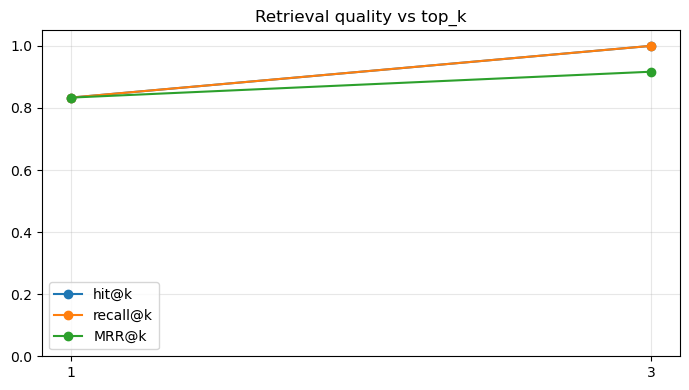

In [8]:
experiment_rows = []
for current_top_k in [1, 3]:
    current_eval = evaluate_retrieval(control_queries, vectorizer, index, base_chunks_df, top_k=current_top_k)
    current_metrics = summarize_metrics(current_eval)
    experiment_rows.append(
        {
            'top_k': current_top_k,
            'hit_at_k': current_metrics['hit_at_k'],
            'recall_at_k': current_metrics['recall_at_k'],
            'mrr_at_k': current_metrics['mrr_at_k'],
        }
    )

experiment_df = pd.DataFrame(experiment_rows)
display(experiment_df)

plt.figure(figsize=(7, 4))
plt.plot(experiment_df['top_k'], experiment_df['hit_at_k'], marker='o', label='hit@k')
plt.plot(experiment_df['top_k'], experiment_df['recall_at_k'], marker='o', label='recall@k')
plt.plot(experiment_df['top_k'], experiment_df['mrr_at_k'], marker='o', label='MRR@k')
plt.xticks([1, 3])
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.title('Retrieval quality vs top_k')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'retrieval_quality_plot.png', dpi=160)
plt.show()


In [9]:
with open(ARTIFACTS_DIR / 'retrieval_metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(
        {
            'base_pipeline': {
                'chunk_size': CHUNK_SIZE,
                'overlap': CHUNK_OVERLAP,
                'top_k': TOP_K,
                **retrieval_metrics,
            },
            'experiment_top_k': experiment_df.to_dict(orient='records'),
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

chunk_examples_df = base_chunks_df[['chunk_id', 'doc_id', 'chunk_len', 'chunk_text']].head(12)
chunk_examples_df.to_csv(ARTIFACTS_DIR / 'chunk_examples.csv', index=False)
print('Сохранены дополнительные артефакты: retrieval_metrics_summary.json, retrieval_quality_plot.png, chunk_examples.csv')


Сохранены дополнительные артефакты: retrieval_metrics_summary.json, retrieval_quality_plot.png, chunk_examples.csv


In [10]:
updated_chunks_df = build_chunks(UPDATED_DOCUMENTS, chunk_size=CHUNK_SIZE, overlap=CHUNK_OVERLAP)
updated_vectorizer, updated_vectors, updated_index = build_vector_index(updated_chunks_df)

before_after_queries = pd.DataFrame([
    {'query': 'Можно ли скачать уроки в приложении и как работает офлайн-доступ?'},
    {'query': 'Какие документы нужны для налогового вычета и сколько их готовят?'},
    {'query': 'Что такое заморозка потока и когда ее можно запросить?'},
    {'query': 'Можно ли скачать запись вебинара на устройство?'},
    {'query': 'Что происходит с дедлайнами после разморозки участия?'},
])

comparison_rows = []
for query in before_after_queries['query']:
    before = search_chunks(query, vectorizer, index, base_chunks_df, top_k=TOP_K * 3)
    after = search_chunks(query, updated_vectorizer, updated_index, updated_chunks_df, top_k=TOP_K * 3)
    before_sources = unique_preserve_order(before['doc_id'].tolist())[:TOP_K]
    after_sources = unique_preserve_order(after['doc_id'].tolist())[:TOP_K]
    comparison_rows.append(
        {
            'query': query,
            'before_retrieved_sources': '|'.join(before_sources),
            'after_retrieved_sources': '|'.join(after_sources),
            'changed': before_sources != after_sources,
        }
    )

before_after_df = pd.DataFrame(comparison_rows)
before_after_df.to_csv(ARTIFACTS_DIR / 'retrieval_before_after_update.csv', index=False)
print('Число документов после обновления:', len(UPDATED_DOCUMENTS))
print('Число чанков после обновления:', len(updated_chunks_df))
display(before_after_df)


Число документов после обновления: 15
Число чанков после обновления: 51


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Можно ли скачать уроки в приложении и как работает офлайн-доступ?,doc_07|doc_10|doc_06,doc_13|doc_06|doc_04,True
1,Какие документы нужны для налогового вычета и сколько их готовят?,doc_08|doc_02|doc_10,doc_14|doc_08|doc_02,True
2,Что такое заморозка потока и когда ее можно запросить?,doc_11|doc_01|doc_03,doc_15|doc_11|doc_01,True
3,Можно ли скачать запись вебинара на устройство?,doc_07|doc_08|doc_04,doc_07|doc_13|doc_08,True
4,Что происходит с дедлайнами после разморозки участия?,doc_01|doc_03|doc_07,doc_15|doc_01|doc_03,True


In [11]:
def run_mini_rag(question: str, vectorizer, index, chunks_df: pd.DataFrame, top_k: int = 3) -> dict:
    retrieved = search_chunks(question, vectorizer, index, chunks_df, top_k=top_k * 2)
    answer = generate_answer(question, retrieved)
    return {
        'question': question,
        'answer': answer,
        'retrieved_sources': '|'.join(unique_preserve_order(retrieved['doc_id'].tolist())[:top_k]),
        'top_context_preview': ' '.join(retrieved['chunk_text'].head(2).tolist())[:500],
    }


rag_questions = [
    'Как получить сертификат после завершения курса?',
    'Когда появляется запись вебинара и можно ли ее скачать?',
    'Как работает налоговый вычет по оплате курса?',
    'Что будет, если домашняя работа отмечена как плагиат?',
    'Можно ли заморозить участие в интенсиве и что будет с дедлайнами?',
]

rag_examples = [run_mini_rag(question, updated_vectorizer, updated_index, updated_chunks_df, top_k=TOP_K) for question in rag_questions]
rag_examples_df = pd.DataFrame(rag_examples)
rag_examples_df.to_csv(ARTIFACTS_DIR / 'rag_examples.csv', index=False)
display(rag_examples_df[['question', 'answer', 'retrieved_sources']])


,question,answer,retrieved_sources
0,Как получить сертификат после завершения курса?,До завершения проверки сертификат и доступ к следующему модулю могут быть временно приостановлены. Сертификат о завершении курса в DataCraft выдается автома...,doc_09|doc_06|doc_10
1,Когда появляется запись вебинара и можно ли ее скачать?,"Скачать запись на устройство нельзя, если это отдельно не разрешено организатором. Скачать полную запись на устройство нельзя, если программа не содержит от...",doc_07|doc_13|doc_10
2,Как работает налоговый вычет по оплате курса?,"В комплект обычно входят договор, кассовые чеки, акт оказанных услуг и справка об оплате. Вместе с записью команда курса добавляет презентацию, ноутбук преп...",doc_05|doc_06|doc_14
3,"Что будет, если домашняя работа отмечена как плагиат?","Если работа отмечена как подозрительная, ее могут отправить на дополнительное ревью. Базовое правило такое: домашняя работа считается сданной вовремя, если ...",doc_10|doc_04|doc_08
4,Можно ли заморозить участие в интенсиве и что будет с дедлайнами?,"Для большинства самостоятельных курсов DataCraft действует пробный период 7 дней. В течение пробного периода студент может открыть первые модули, пройти кви...",doc_03|doc_01|doc_15


In [12]:
for row in rag_examples:
    print('\nQUESTION:', row['question'])
    print('ANSWER:', row['answer'])
    print('SOURCES:', row['retrieved_sources'])



QUESTION: Как получить сертификат после завершения курса?
ANSWER: До завершения проверки сертификат и доступ к следующему модулю могут быть временно приостановлены. Сертификат о завершении курса в DataCraft выдается автоматически после выполнения трех условий. На программах с проектным треком итоговый проект стартует после завершения основных модулей.
SOURCES: doc_09|doc_06|doc_10

QUESTION: Когда появляется запись вебинара и можно ли ее скачать?
ANSWER: Скачать запись на устройство нельзя, если это отдельно не разрешено организатором. Скачать полную запись на устройство нельзя, если программа не содержит отдельного разрешения. Скачать полную запись на устройство нельзя, если программа не содержит
SOURCES: doc_07|doc_13|doc_10

QUESTION: Как работает налоговый вычет по оплате курса?
ANSWER: В комплект обычно входят договор, кассовые чеки, акт оказанных услуг и справка об оплате. Вместе с записью команда курса добавляет презентацию, ноутбук преподавателя и список дополнительных ссылок,

## Краткий анализ ошибок и ограничений

1. **Смешение тем (retrieval):**  
   В вопросах про дедлайны, плагиат или заморозку в выдачу попадают чанки с похожей лексикой (например, "дедлайн", "доступ"), но из разных разделов.  
   → Проблема: TF-IDF ориентируется на совпадение слов, а не на смысл.

2. **Неполный или смещённый контекст (retrieval + база знаний):**  
   В вопросе про заморозку участие модель вернула чанки про пробный период, потому что они лексически похожи.  
   → Проблема: в базе знаний либо мало информации про заморозку, либо она плохо выделена.

3. **Избыточные ответы (сборка контекста):**  
   Mini-RAG просто объединяет найденные чанки, поэтому ответы могут:
   - повторяться  
   - содержать лишние детали  
   → Проблема: отсутствует нормальная генерация/сжатие ответа.

4. **Чувствительность к формулировке запроса:**  
   Если вопрос задан неформально или без ключевых слов (например, “что будет дальше с курсом”), retrieval может вернуть менее релевантные чанки.  
   → Проблема: TF-IDF хуже работает с синонимами и разговорной речью.
